___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Hierarchal Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## The Data

In [2]:
df = pd.read_csv('../DATA/cluster_mpg.csv')

In [3]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [7]:
df['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

In [8]:
df_w_dummies = pd.get_dummies(df.drop('name',axis=1))

In [9]:
df_w_dummies

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,False,False,True
388,44.0,4,97.0,52.0,2130,24.6,82,True,False,False
389,32.0,4,135.0,84.0,2295,11.6,82,False,False,True
390,28.0,4,120.0,79.0,2625,18.6,82,False,False,True


-----

In [10]:
from sklearn.preprocessing import MinMaxScaler
# For something like hierarchical clustering, I would actually recommend that for your scaling, you use the MinMaxScaler, which will scale all of the features to be between 0 and 1. 
# But it essentially allows us to have a easier time imagining what the max distance could be between two data points, because the max distance between two data points will be the square root of the number of features that we have.
# This is because hierarchical clustering is very sensitive to outliers, and the MinMaxScaler will help to mitigate the effect of outliers on the clustering results.

In [11]:
scaler = MinMaxScaler()

In [12]:
scaled_data = scaler.fit_transform(df_w_dummies)

In [13]:
scaled_data

array([[0.2393617 , 1.        , 0.61757106, ..., 0.        , 0.        ,
        1.        ],
       [0.15957447, 1.        , 0.72868217, ..., 0.        , 0.        ,
        1.        ],
       [0.2393617 , 1.        , 0.64599483, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.61170213, 0.2       , 0.17312661, ..., 0.        , 0.        ,
        1.        ],
       [0.50531915, 0.2       , 0.13436693, ..., 0.        , 0.        ,
        1.        ],
       [0.58510638, 0.2       , 0.13178295, ..., 0.        , 0.        ,
        1.        ]], shape=(392, 10))

In [14]:
scaled_df = pd.DataFrame(scaled_data,columns=df_w_dummies.columns)

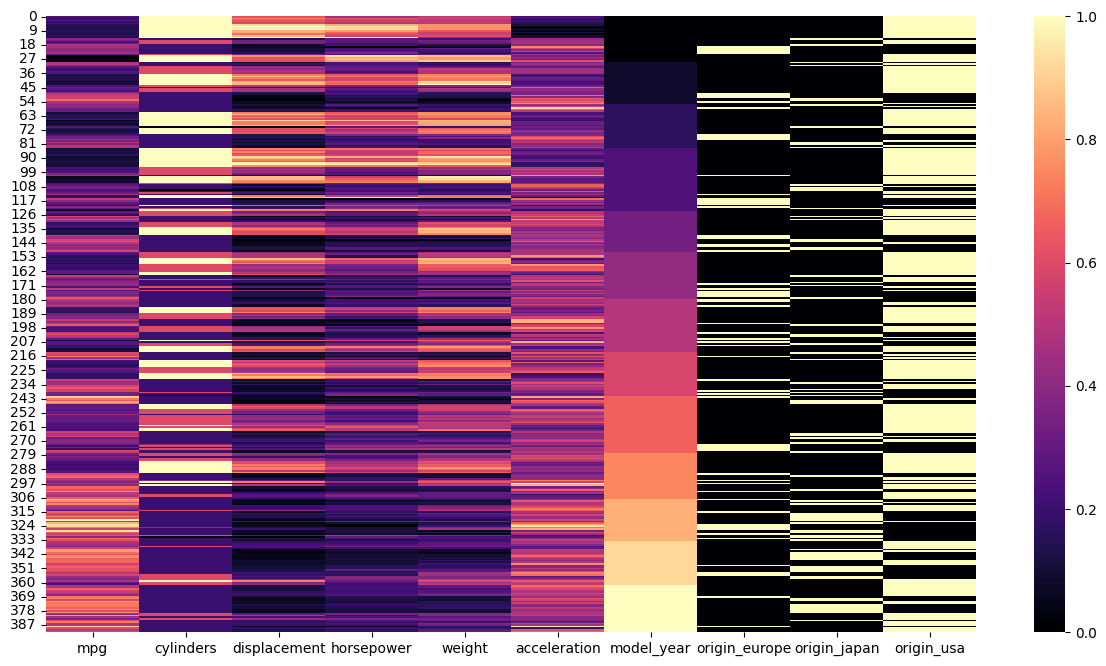

In [15]:
plt.figure(figsize=(15,8))
sns.heatmap(scaled_df,cmap='magma');

<Figure size 1500x800 with 0 Axes>

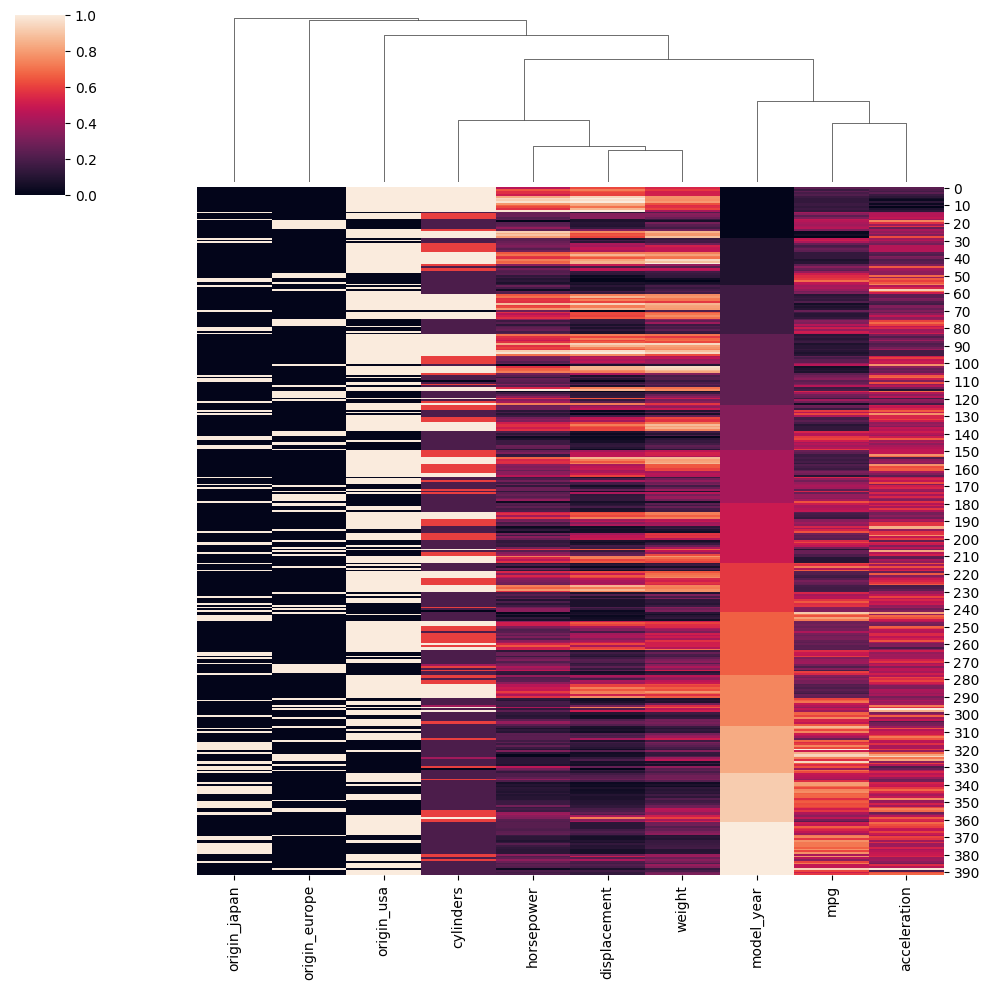

In [16]:
plt.figure(figsize=(15,8), dpi=100)
sns.clustermap(scaled_df,row_cluster=False)

<Axes: >

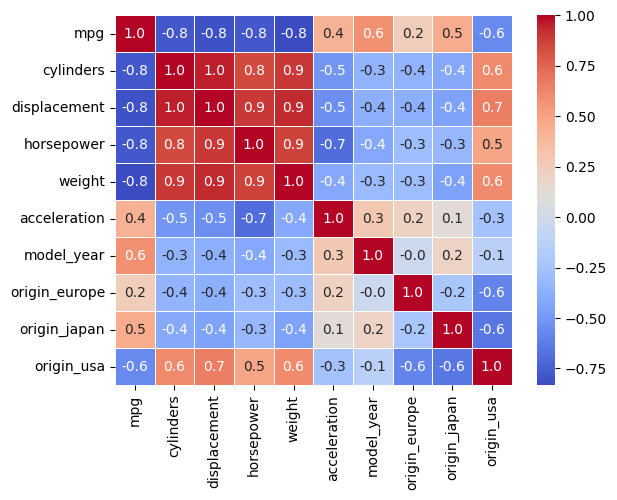

In [17]:
sns.heatmap(scaled_df.corr(numeric_only=True), annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)

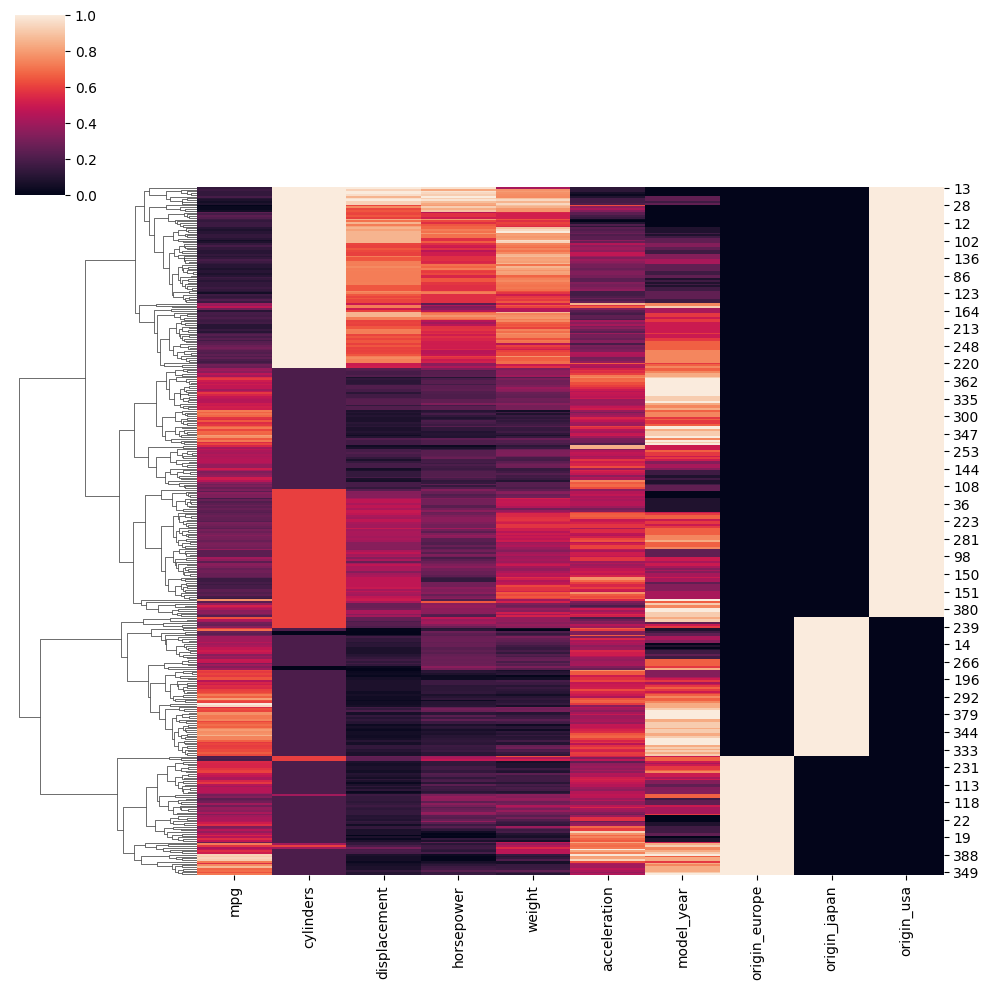

In [18]:
sns.clustermap(scaled_df,col_cluster=False)

## Using Scikit-Learn

In [19]:
from sklearn.cluster import AgglomerativeClustering

In [34]:
help(AgglomerativeClustering)

Help on class AgglomerativeClustering in module sklearn.cluster._agglomerative:

class AgglomerativeClustering(sklearn.base.ClusterMixin, sklearn.base.BaseEstimator)
 |  AgglomerativeClustering(n_clusters=2, *, metric='euclidean', memory=None, connectivity=None, compute_full_tree='auto', linkage='ward', distance_threshold=None, compute_distances=False)
 |  
 |  Agglomerative Clustering.
 |  
 |  Recursively merges pair of clusters of sample data; uses linkage distance.
 |  
 |  Read more in the :ref:`User Guide <hierarchical_clustering>`.
 |  
 |  Parameters
 |  ----------
 |  n_clusters : int or None, default=2
 |      The number of clusters to find. It must be ``None`` if
 |      ``distance_threshold`` is not ``None``.
 |  
 |  metric : str or callable, default="euclidean"
 |      Metric used to compute the linkage. Can be "euclidean", "l1", "l2",
 |      "manhattan", "cosine", or "precomputed". If linkage is "ward", only
 |      "euclidean" is accepted. If "precomputed", a distance 

In [20]:
model = AgglomerativeClustering(n_clusters=4)

In [21]:
cluster_labels = model.fit_predict(scaled_df)

In [22]:
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 3, 2, 2, 2,
       2, 2, 0, 1, 1, 1, 1, 3, 0, 3, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 2, 0, 3, 0, 2, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 2, 2, 0, 3, 3, 0, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 3, 0, 3,
       3, 0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 3, 0, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 0, 2, 2, 3, 3, 2, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 3, 0, 0, 0, 3, 2, 3, 0, 2, 0, 2,
       2, 2, 2, 3, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 3, 0,
       0, 0, 0, 2, 3, 3, 0, 2, 1, 2, 3, 2, 1, 1, 1, 1, 3, 0, 2, 0, 3, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 3, 0, 0, 0, 3, 2, 3, 2, 3,
       2, 0, 3, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 3, 3, 0, 3, 0, 0, 3, 2, 2, 2, 2, 2, 3, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 3, 0, 0, 2, 1, 2, 1, 0, 0,

<Axes: xlabel='mpg', ylabel='weight'>

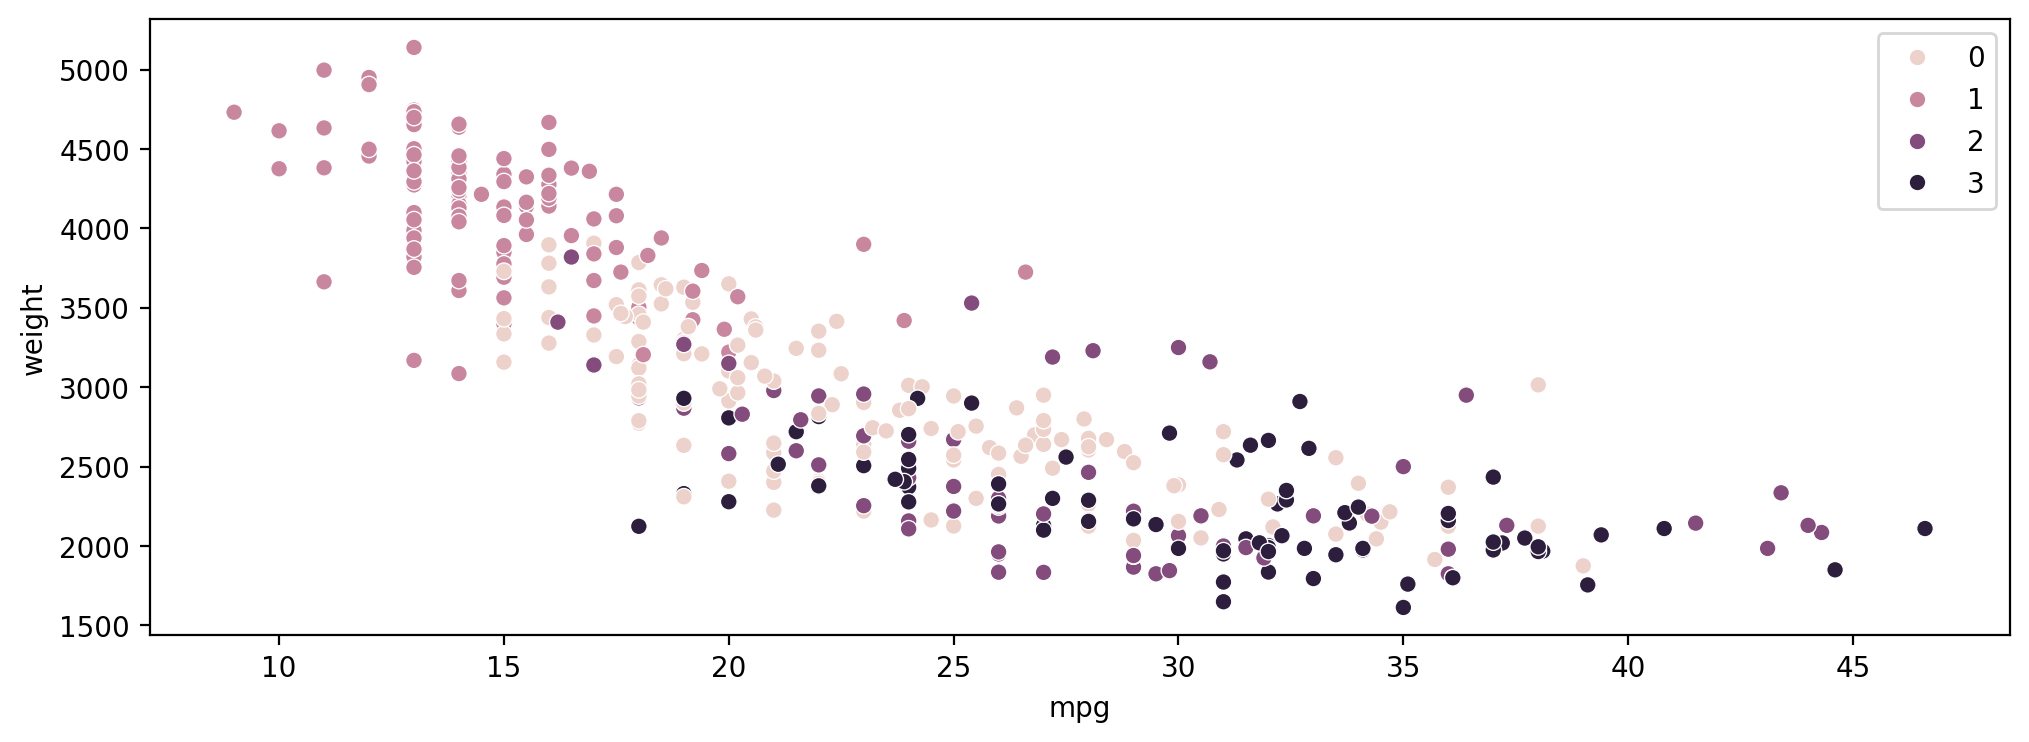

In [23]:
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(data=df,x='mpg',y='weight',hue=cluster_labels)

<Axes: xlabel='mpg', ylabel='horsepower'>

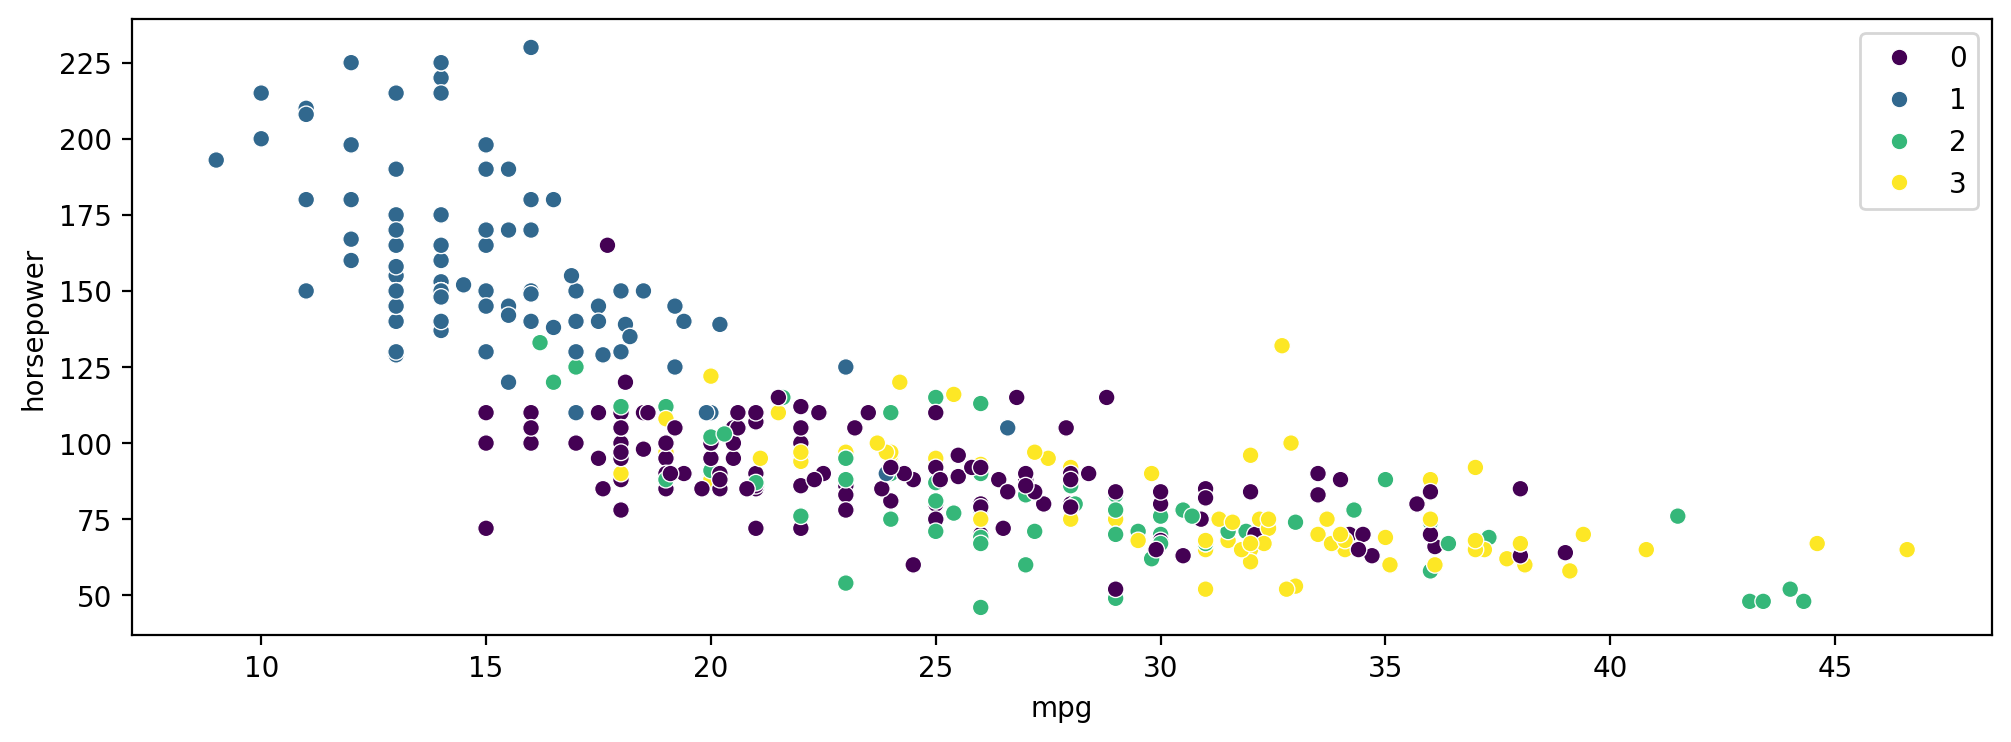

In [24]:
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(data=df,x='mpg',y='horsepower',hue=cluster_labels,
                palette='viridis')

In [ ]:
# If we have a datatset which was scaled using the MinMaxScaler, then the maximum distance between two data points will be the square root of the number of features that we have.
# so in this case, we have 10 features, so the maximum distance between two data points will be the square root of 10, which is approximately 3.16.
# max distance possible = sqrt(N_features) = np.sqrt(scaled_df.shape[1])

In [25]:
# MAX DISTANCE POSSIBLE BETWEEN TWO POINTS (MIN/MAX SCALING)
np.sqrt(len(scaled_df.columns))

np.float64(3.1622776601683795)

## Exploring Number of Clusters with Dendrograms

Make sure to read the documentation online!
https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

#### Assuming every point starts as its own cluster

In [ ]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=0)
# When you use the distance_threshold parameter, you need to set n_clusters to None, because the number of clusters will be determined by the distance threshold.
# If distance_threshold is set to 0, then we will end up with as many clusters as there are data points, because each data point will be considered its own cluster.
# If you choose a numeric value for distance_threshold you should choose a value that is between 0 and the maximum distance possible between two data points, 
# which in this case is approximately 3.16. Also set n_clusters to None when using distance_threshold, because the number of clusters will be determined by the distance threshold.

In [27]:
cluster_labels = model.fit_predict(scaled_df)

In [28]:
cluster_labels

array([247, 252, 360, 302, 326, 381, 384, 338, 300, 279, 217, 311, 377,
       281, 232, 334, 272, 375, 354, 333, 317, 345, 329, 289, 305, 383,
       290, 205, 355, 269, 202, 144, 245, 297, 386, 358, 199, 337, 330,
       339, 293, 352, 283, 196, 253, 168, 378, 331, 201, 268, 256, 361,
       250, 197, 246, 371, 324, 230, 203, 261, 380, 376, 308, 389, 332,
       306, 236, 391, 350, 274, 288, 313, 231, 298, 100, 295, 210, 248,
       187, 390, 373, 266, 307, 379, 212, 357, 191, 314, 208, 249, 343,
       294, 374, 322, 323, 362, 188, 296, 369, 286, 251, 229, 244, 285,
       349, 365, 259, 213, 276, 215, 222, 204, 359, 287, 166, 387, 291,
       220, 216, 260, 129, 367, 340, 346, 301, 342, 228, 388, 370, 218,
       255, 327, 347, 278, 271, 258, 282, 318, 273, 123, 172, 382, 363,
       356, 195, 280, 239, 364, 267, 351, 186, 257, 277, 299, 127, 366,
       234, 385, 192, 372, 292, 233, 270, 263, 133, 165, 161, 198,  97,
       315, 134, 207, 147, 175, 262, 348,  98, 214,  48, 353, 17

In [ ]:
print(f"Number of unique clusters when distance_threshold=0: {len(np.unique(cluster_labels))}, Number of data points: {len(scaled_df)}")
# We can see that when we set the distance_threshold to 0, we end up with as many clusters as there are data points, which is 392 in this case. 
# This is because each data point is considered its own cluster when the distance threshold is set to 0.

392 392


In [35]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

## Linkage Model

In [ ]:
linkage_matrix = hierarchy.linkage(model.children_)
# What the linkage function does is it takes the children_ attribute of the model, which contains the hierarchical clustering information, 
# and it computes the linkage matrix that we can use to plot the dendrogram.
# The children_ attribute of the model is a 2D array where each row represents a merge of two clusters, and the columns represent the indices of the clusters that were merged.
# The linkage function takes this information and computes the distances between the clusters that were merged, 
# and it returns a linkage matrix that contains this information in a format that can be used to plot a dendrogram.

In [37]:
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]],
      shape=(390, 4))

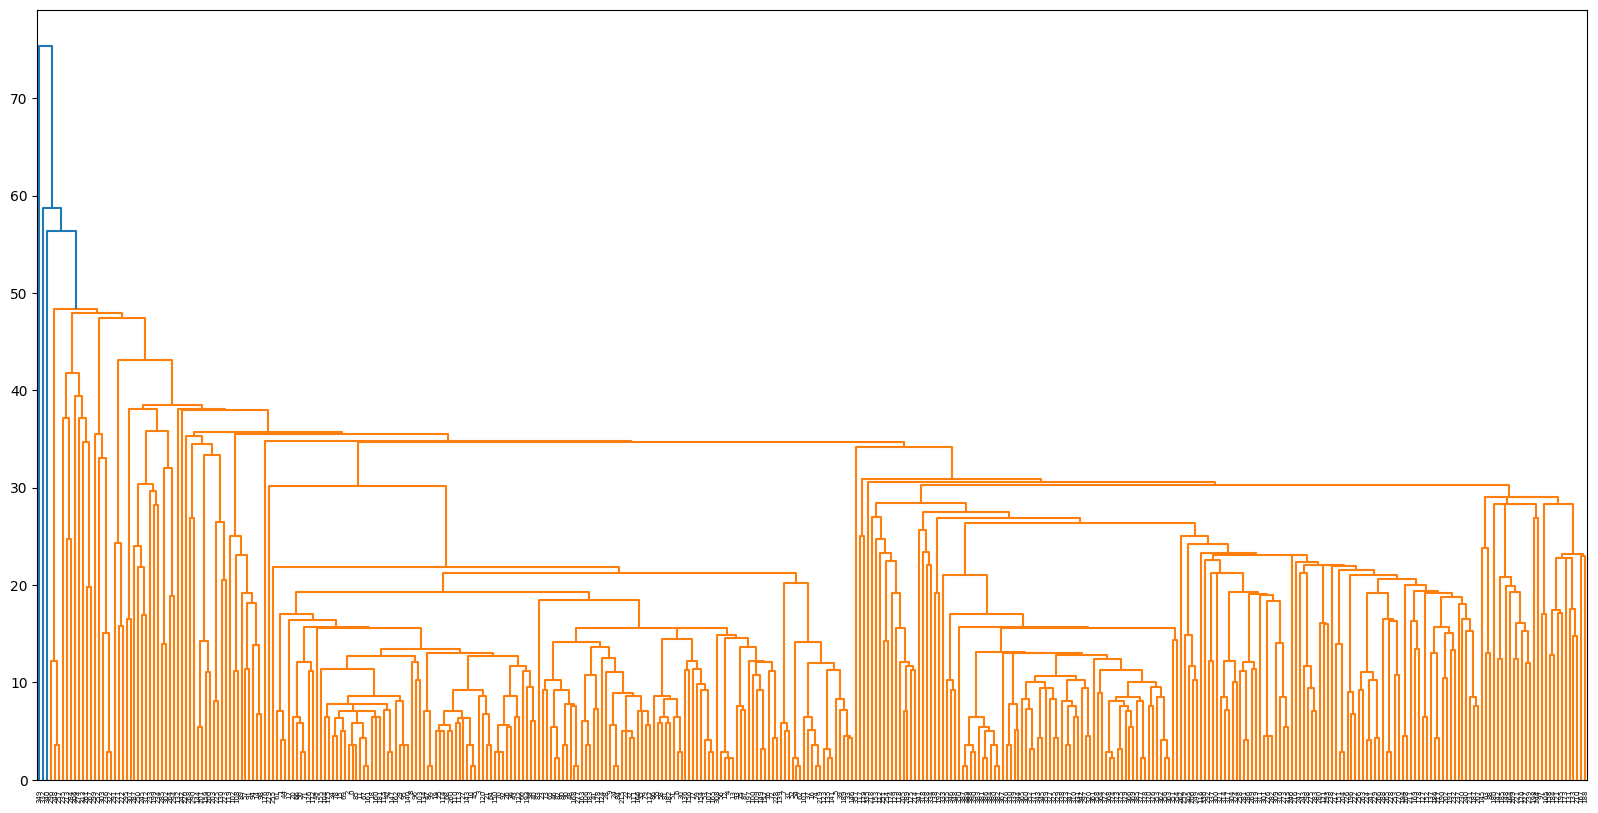

In [38]:
plt.figure(figsize=(20,10))
# Warning! This plot will take awhile!!
dn = hierarchy.dendrogram(linkage_matrix)

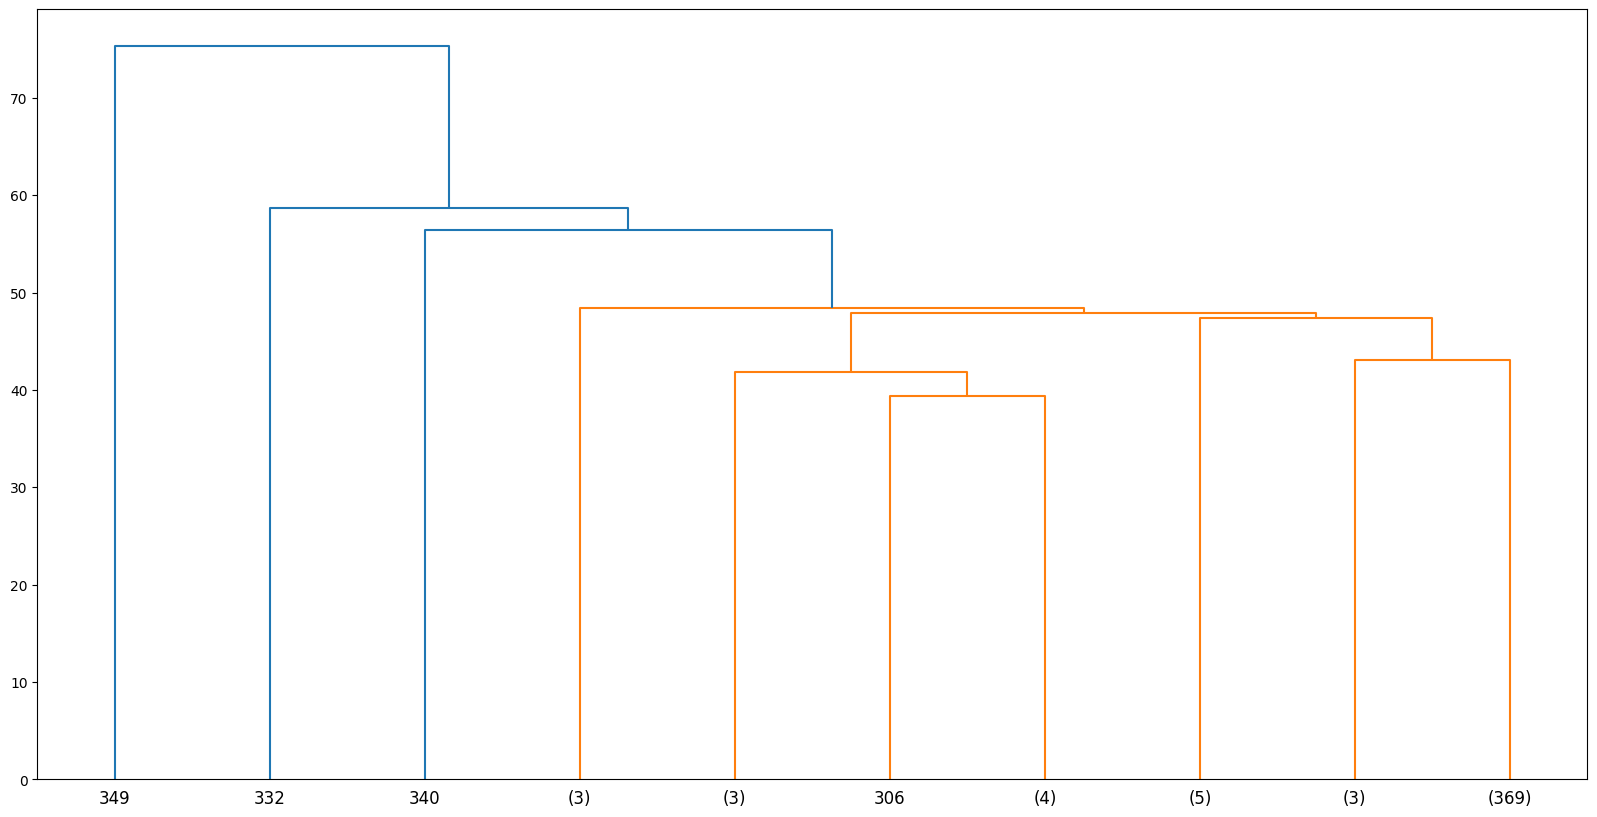

In [ ]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='lastp',p=10)
# When you use thw truncate_mode parameter = 'lastp', it will only show the last p merges in the dendrogram, 
# which can make it easier to visualize the overall structure of the clusters without getting overwhelmed by too much detail.

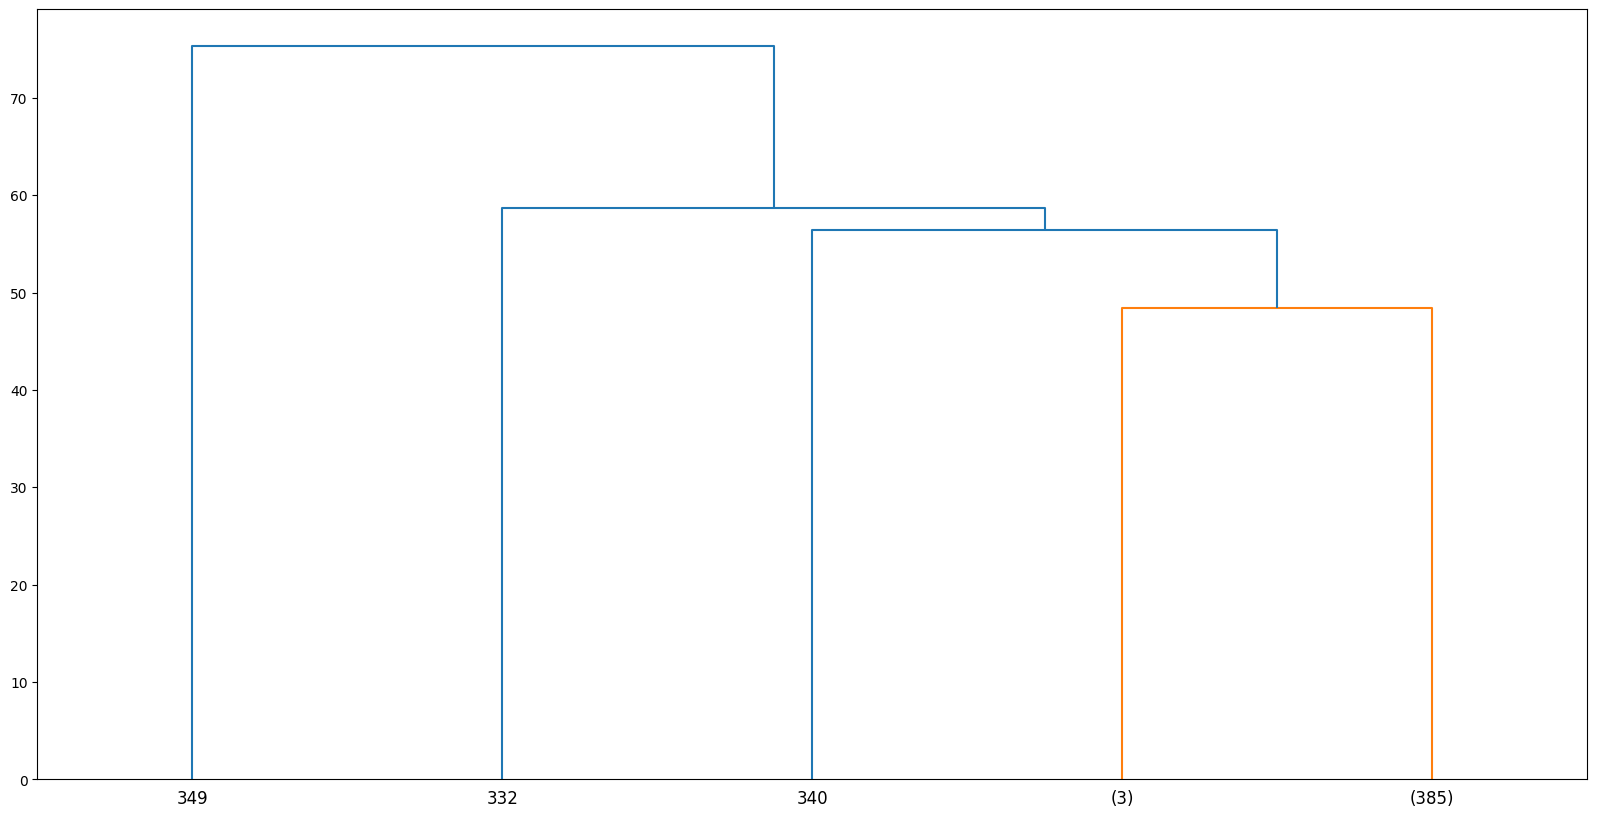

In [ ]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='level',p=3)
# When you use the truncate_mode parameter = 'level', it will only show the merges that occur at a certain level of the dendrogram.
# This can be useful for understanding the overall structure of the clusters and how they are related to each other at different levels of the hierarchy.
# The level parameter specifies the number of levels to show in the dendrogram, and it will only show the merges that occur at those levels.

### Choosing a Threshold Distance

**What is the distance between two points?**

In [41]:
scaled_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,0.384200,0.494388,0.326646,0.317768,0.386897,0.448888,0.498299,0.173469,0.201531,0.625000
std,0.207580,0.341157,0.270398,0.209191,0.240829,0.164218,0.306978,0.379136,0.401656,0.484742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.212766,0.200000,0.095607,0.157609,0.173589,0.343750,0.250000,0.000000,0.000000,0.000000
50%,0.365691,0.200000,0.214470,0.258152,0.337539,0.446429,0.500000,0.000000,0.000000,1.000000
75%,0.531915,1.000000,0.536822,0.434783,0.567550,0.537202,0.750000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# To get a good treshold distance for our dataset, we can choose a important feature in our dataset, like miles per gallon (mpg) and
# take the mimimum and maximum values of that feature, and then we can choose a distance threshold that is somewhere between those two values.


In [42]:
scaled_df['mpg'].idxmax()

320

In [43]:
scaled_df['mpg'].idxmin()

28

In [44]:
# https://stackoverflow.com/questions/1401712/how-can-the-euclidean-distance-be-calculated-with-numpy
a = scaled_df.iloc[320]
b = scaled_df.iloc[28]
dist = np.linalg.norm(a-b)

In [ ]:
dist
# As we can see, the distance between the data point with the highest miles per gallon (mpg) and the data point with the lowest miles per gallon (mpg) is approximately 2.83, 
# which is less than the maximum theoretical distance possible of 3.16.
# So we could choose a distance threshold that is somewhere between 2.83 and 3.16, which would allow us to capture the clusters that are formed by the data points with high and low miles per gallon (mpg) values, while also allowing us to capture the clusters that are formed by the data points with more moderate miles per gallon (mpg) values.


np.float64(2.3852929970374714)

#### Max possible distance?

Recall Euclidean distance: https://en.wikipedia.org/wiki/Euclidean_distance

In [46]:
np.sqrt(len(scaled_df.columns))
# This is a theoretical maximum distance between two data points in our dataset, because we have 10 features and the data is scaled using the MinMaxScaler, which scales all features to be between 0 and 1.
# Is important to note that this is a theoretical maximum distance, and in practice, the actual maximum distance between two data points in our dataset may be less than this value, depending on the distribution of the data and the specific values of the features.
# To get the real maximum distance between two data points in our dataset, we would need to compute the pairwise distances between all data points and find the maximum distance.
# A good estimate of the maximum distance can be obtained by looking at the distance between the data points with the highest and lowest values of an important feature, 
# like miles per gallon (mpg), as we did above.

np.float64(3.1622776601683795)

### Creating a Model Based on Distance Threshold

* distance_threshold
    * The linkage distance threshold above which, clusters will not be merged.

In [47]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=2)

In [48]:
cluster_labels = model.fit_predict(scaled_data)

In [49]:
cluster_labels

array([ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  1,  4,  4,
        4,  1,  0,  0,  0,  0,  0,  4,  3,  3,  3,  3,  1,  7,  1,  4,  4,
        4,  4,  4,  3,  3,  3,  3,  3,  3,  3,  4,  7,  4,  4,  7,  0,  0,
        0,  1,  1,  0,  7,  1,  7,  0,  7,  7,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  1,  3,  3,  3,  3,  0,  0,  0,  0,  7,  1,  1,  7,  1,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  0,
        3,  3,  3,  3,  4,  1,  7,  1,  1,  7,  4,  0,  3,  3,  0,  0,  0,
        0,  3,  0, 10,  3,  4,  4,  4,  1,  7,  1,  7,  4,  4,  4,  3,  3,
        3,  3,  3,  0,  0,  0,  1,  1,  7,  0,  0,  1,  1,  0,  4,  4,  4,
        4,  5,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  1,  7,  4,  7,  1,
        0,  1,  4,  0,  4,  0,  0,  0,  0,  1,  0,  0,  7,  7,  0,  5,  5,
        5,  5,  4,  4,  4,  4,  7,  7,  0,  1,  9,  4,  9,  4,  0,  1,  1,
        7,  0,  5,  8, 10,  0,  5,  5,  5,  5,  1,  2,  8,  7,  1,  5,  5,
        5,  5,  9,  9,  9

In [50]:
np.unique(cluster_labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

### Linkage Matrix

Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage

    A (n-1) by 4 matrix Z is returned. At the i-th iteration, clusters with indices Z[i, 0] and Z[i, 1] are combined to form cluster n + i. A cluster with an index less than n corresponds to one of the original observations. The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2]. The fourth value Z[i, 3] represents the number of original observations in the newly formed cluster.

In [51]:
linkage_matrix = hierarchy.linkage(model.children_)

In [52]:
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]],
      shape=(390, 4))

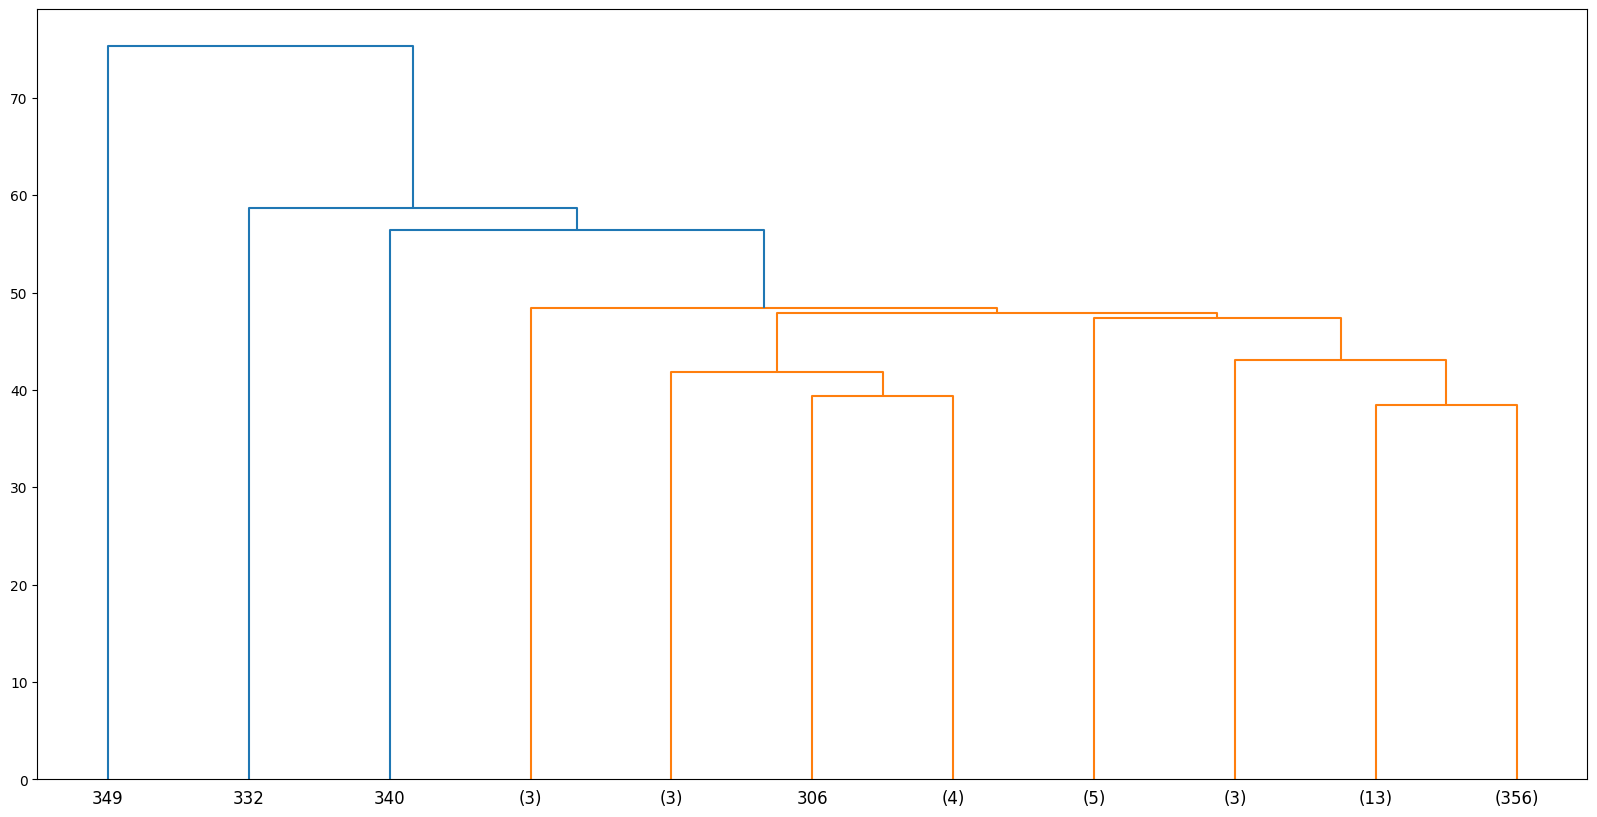

In [53]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='lastp',p=11)